#### 1. Carregamento dos dados
#### 2. Exploração inicial
#### 3. Análise de inadimplência por grade
#### 4. Teste de hipótese
#### 5. Validação do agente de IA
#### 6. Insights e recomendações

In [ ]:
## 1. Carregamento dos dados
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.proportion import proportions_ztest


# Leitura do dataset fornecido e limitamos para 100k linhas para otimizar performance
df = pd.read_csv("./accepted_2007_to_2018q4/accepted_2007_to_2018Q4.csv", nrows=100000, low_memory=False )

df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


#### 2. Exploração inicial

In [ ]:

print(df.shape)
df.info() 
# print(df.columns) 

(100000, 151)
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 151 entries, id to settlement_term
dtypes: float64(114), int64(1), str(36)
memory usage: 115.2 MB


In [ ]:
list(df.columns)

['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'last_fico_range_high',
 'last_fico_range_low',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 '

In [ ]:
# Seleção de colunas relevantes para análise de risco de crédito
colunas_relevantes = [
    'loan_amnt',
    'funded_amnt',
    'funded_amnt_inv',
    'term',
    'int_rate',
    'installment',
    'grade',
    'sub_grade',
    'emp_length',
    'home_ownership',
    'annual_inc',
    'verification_status',
    'issue_d',
    'loan_status',
    'purpose',
    'addr_state',
    'zip_code',
    'dti',
    'fico_range_low',
    'fico_range_high',
    'delinq_2yrs',
    'pub_rec',
    'revol_bal',
    'revol_util',
    'total_acc',
    'inq_last_6mths',
    'earliest_cr_line'
]

# Criar um novo DataFrame apenas com essas colunas
df_reduzido = df[colunas_relevantes].copy()

# Conferir o resultado
print(df_reduzido.shape)
df_reduzido.head()

(100000, 27)


,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,...,dti,fico_range_low,fico_range_high,delinq_2yrs,pub_rec,revol_bal,revol_util,total_acc,inq_last_6mths,earliest_cr_line
0,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,...,5.91,675.0,679.0,0.0,0.0,2765.0,29.7,13.0,1.0,Aug-2003
1,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,...,16.06,715.0,719.0,1.0,0.0,21470.0,19.2,38.0,4.0,Dec-1999
2,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,...,10.78,695.0,699.0,0.0,0.0,7869.0,56.2,18.0,0.0,Aug-2000
3,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,10+ years,MORTGAGE,...,17.06,785.0,789.0,0.0,0.0,7802.0,11.6,17.0,0.0,Sep-2008
4,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,...,25.37,695.0,699.0,1.0,0.0,21929.0,64.5,35.0,3.0,Jun-1998


In [ ]:
## Limpeza e padronização de dados (ESSENCIAL para BI)

# Converter colunas numéricas
colunas_numericas = [
    'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'installment',
    'annual_inc', 'dti', 'fico_range_low', 'fico_range_high',
    'delinq_2yrs', 'pub_rec', 'revol_bal', 'total_acc', 'inq_last_6mths'
]

for col in colunas_numericas:
    df_reduzido[col] = pd.to_numeric(df_reduzido[col], errors='coerce')


# Tratar colunas com porcentagem (%)
df_reduzido['int_rate'] = pd.to_numeric(
    df_reduzido['int_rate'].astype(str).str.replace('%', ''),
    errors='coerce'
)

df_reduzido['revol_util'] = pd.to_numeric(
    df_reduzido['revol_util'].astype(str).str.replace('%', ''),
    errors='coerce'
)


# Converter prazo (term: "36 months" → 36)
df_reduzido['term'] = pd.to_numeric(
    df_reduzido['term'].astype(str).str.extract(r'(\d+)')[0],
    errors='coerce'
)


# Criar faixa de renda (para BI)
df_reduzido['faixa_renda'] = pd.qcut(
    df_reduzido['annual_inc'],
    q=4,
    labels=['Baixa', 'Média Baixa', 'Média Alta', 'Alta']
)

# Criar coluna binária de inadimplência
df_reduzido['inadimplente'] = np.where(df_reduzido['loan_status'] == 'Charged Off', 1, 0)

In [ ]:

print("\nTipos de dados após limpeza:")
print(df_reduzido.dtypes)


Tipos de dados após limpeza:
loan_amnt               float64
funded_amnt             float64
funded_amnt_inv         float64
term                      int64
int_rate                float64
installment             float64
grade                       str
sub_grade                   str
emp_length                  str
home_ownership              str
annual_inc              float64
verification_status         str
issue_d                     str
loan_status                 str
purpose                     str
addr_state                  str
zip_code                    str
dti                     float64
fico_range_low          float64
fico_range_high         float64
delinq_2yrs             float64
pub_rec                 float64
revol_bal               float64
revol_util              float64
total_acc               float64
inq_last_6mths          float64
earliest_cr_line            str
faixa_renda            category
inadimplente              int64
dtype: object


#### 3. Análise de inadimplência por grade

Taxa de inadimplência por grade:
grade
A    0.051849
B    0.120207
C    0.198746
D    0.282974
E    0.346713
F    0.437534
G    0.506361
Name: inadimplente, dtype: float64

Taxa média da carteira: 17.60%
Taxa média das grades D/E: 30.48%

Estatística z: 41.9935, p-valor: 0.0000
➡️ Rejeitamos H0: inadimplência em D/E é significativamente maior que a média geral.


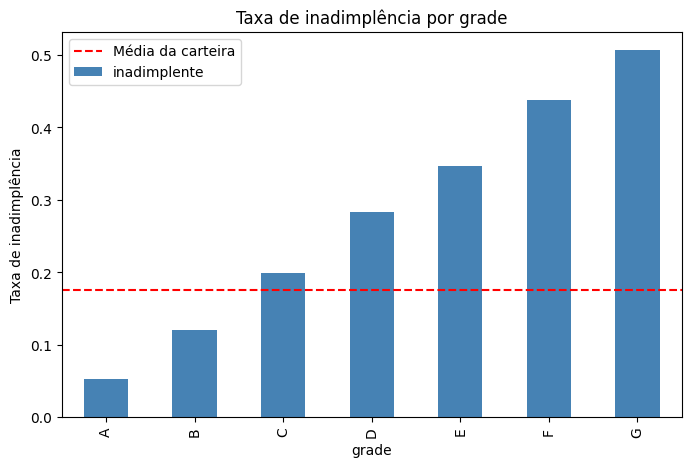

In [ ]:
# Criamos uma variável binária:
#   1 = inadimplente (Charged Off)
#   0 = não inadimplente

#  Calcular taxa de inadimplência por grade de risco para entender a relação entre rating e default
taxa_por_grade = df_reduzido.groupby('grade')['inadimplente'].mean().sort_index()
print("Taxa de inadimplência por grade:")
print(taxa_por_grade)

#  Calcular taxa média da carteira e das grades D/E
taxa_media = df_reduzido['inadimplente'].mean()
taxa_DE = df_reduzido[df_reduzido['grade'].isin(['D','E'])]['inadimplente'].mean()

print(f"\nTaxa média da carteira: {taxa_media:.2%}")
print(f"Taxa média das grades D/E: {taxa_DE:.2%}")



#### 4. Teste de hipótese

In [ ]:
## Teste de hipótese (z-test para proporções) -
# H0 é a hipótese nula
    # H0: inadimplência de D/E <= média da carteira
    # H1: inadimplência de D/E > média da carteira

# Contagem de inadimplentes e total em D/E
inad_DE = df_reduzido[df_reduzido['grade'].isin(['D','E'])]['inadimplente'].sum()
total_DE = df_reduzido[df_reduzido['grade'].isin(['D','E'])].shape[0]

# Contagem de inadimplentes e total na carteira
inad_total = df_reduzido['inadimplente'].sum()
total_total = df_reduzido.shape[0]

count = np.array([inad_DE, inad_total])
nobs = np.array([total_DE, total_total])

stat, pval = proportions_ztest(count, nobs, alternative='larger')
print(f"\nEstatística z: {stat:.4f}, p-valor: {pval:.4f}")

# Interpretação:
# O p-valor é a probabilidade de observarmos os resultados obtidos
# Se p-valor < 0.05 → rejeitamos H0 e concluímos que a inadimplência de D/E é estatisticamente maior que a média

if pval < 0.05:
    print("➡️ Rejeitamos H0: inadimplência em D/E é significativamente maior que a média geral.")
else:
    print("➡️ Não rejeitamos H0: não há evidência de que D/E tenha inadimplência maior que a média.")

# 5. Gráfico de barras
plt.figure(figsize=(8,5))
taxa_por_grade.plot(kind='bar', color='steelblue')
plt.axhline(taxa_media, color='red', linestyle='--', label='Média da carteira')
plt.title('Taxa de inadimplência por grade')
plt.ylabel('Taxa de inadimplência')
plt.legend()
plt.show()

# Insight:
# A confirmação estatística sugere que grades D/E têm risco maior, validando parcialmente a hipótese do time de risco

#### 5. Validação do agente de IA

In [ ]:
# Análise focada no segmento "debt_consolidation" para validar resposta do agente de IA

# Métricas calculadas:
# - proporção na carteira
# - taxa de inadimplência
# - ticket médio
# - distribuição de risco (grade)
# - taxa de juros


# 1. Filtrar apenas clientes com finalidade 'debt_consolidation'
df_debt = df_reduzido[df_reduzido['purpose'] == 'debt_consolidation']

# 2. Proporção desse segmento na carteira
prop_debt = len(df_debt) / len(df_reduzido)

# 3. Taxa de inadimplência desse segmento
taxa_debt = df_debt['inadimplente'].mean()

# 4. Ticket médio (valor médio do empréstimo)
ticket_medio = df_debt['loan_amnt'].mean()

# 5. Distribuição por grade
dist_grade = df_debt['grade'].value_counts(normalize=True)


# 6. Taxa média de juros
juros_medio = df_debt['int_rate'].mean()

print(f"Proporção na carteira: {prop_debt:.2%}")
print(f"Taxa de inadimplência: {taxa_debt:.2%}")
print(f"Ticket médio: {ticket_medio:,.2f}")
print("\nDistribuição por grade:")
print(dist_grade)
print(f"\nTaxa média de juros: {juros_medio:.2f}")

Proporção na carteira: 56.91%
Taxa de inadimplência: 19.04%
Ticket médio: 15,789.40

Distribuição por grade:
grade
C    0.302527
B    0.293039
D    0.149085
A    0.145816
E    0.082844
F    0.021998
G    0.004691
Name: proportion, dtype: float64

Taxa média de juros: 12.65


In [ ]:
# Valores fornecidos pelo agente de IA
ia_prop = 0.48
ia_inad = 0.123
ia_ticket = 72000
ia_juros = 13.8

print("\nComparação com IA:")
print(f"Proporção -> Real: {prop_debt:.2%} | IA: {ia_prop:.2%}")
print(f"Inadimplência -> Real: {taxa_debt:.2%} | IA: {ia_inad:.2%}")
print(f"Ticket médio -> Real: {ticket_medio:,.2f} | IA: {ia_ticket:,.2f}")
print(f"Juros médio -> Real: {juros_medio:.2f} | IA: {ia_juros:.2f}")


Comparação com IA:
Proporção -> Real: 56.91% | IA: 48.00%
Inadimplência -> Real: 19.04% | IA: 12.30%
Ticket médio -> Real: 15,789.40 | IA: 72,000.00
Juros médio -> Real: 12.65 | IA: 13.80


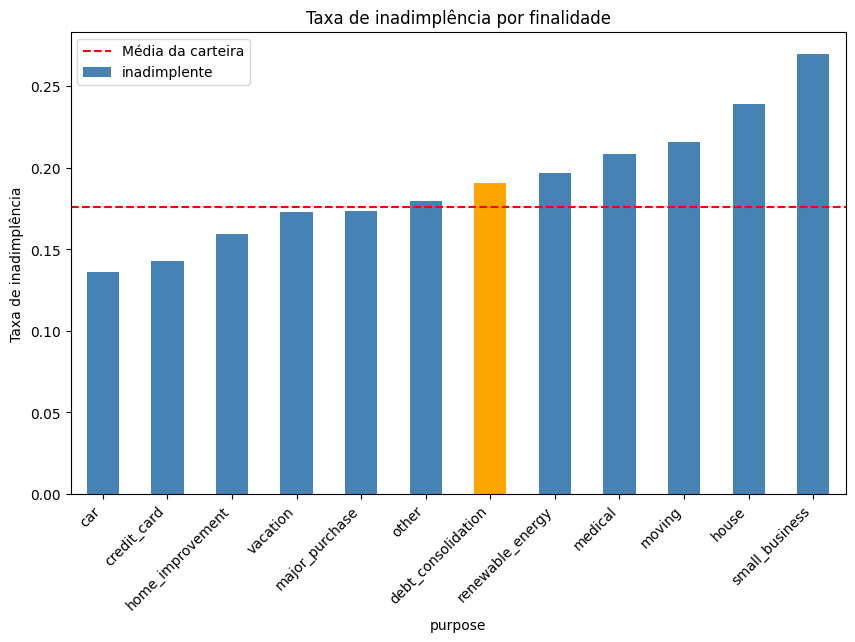

In [ ]:
# Análise de inadimplência por finalidade do empréstimo para identificar segmentos de maior risco

# Agrupar por finalidade e calcular taxa de inadimplência
taxa_por_purpose = df_reduzido.groupby('purpose')['inadimplente'].mean().sort_values()

# Plotar gráfico de barras
plt.figure(figsize=(10,6))
colors = ['steelblue' if p != 'debt_consolidation' else 'orange' for p in taxa_por_purpose.index]
taxa_por_purpose.plot(kind='bar', color=colors)

plt.axhline(df_reduzido['inadimplente'].mean(), color='red', linestyle='--', label='Média da carteira')
plt.title('Taxa de inadimplência por finalidade')
plt.ylabel('Taxa de inadimplência')
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
# Score médio do FICO
df_reduzido['fico_medio'] = (df_reduzido['fico_range_low'] + df_reduzido['fico_range_high']) / 2

# Ano/Mês (ESSENCIAL para séries temporais)
df_reduzido['issue_d'] = pd.to_datetime(df_reduzido['issue_d'], format='%b-%Y', errors='coerce')
df_reduzido['ano_mes'] = df_reduzido['issue_d'].dt.strftime('%Y-%m')

# Faixa de DTI (muito útil pra negócio)
df_reduzido['faixa_dti'] = pd.cut(
    df_reduzido['dti'],
    bins=[0,10,20,30,100],
    labels=['Baixo','Médio','Alto','Muito Alto']
)

### 6. Insights e recomendações

#### Insight (não óbvio)
Apesar das grades D/E apresentarem maior taxa de inadimplência,
o maior impacto na carteira pode vir das grades B e C
devido ao maior volume de empréstimos.

Isso sugere que o risco não está apenas na taxa, mas também na concentração da carteira.

#### Avaliação do agente

- A resposta parece plausível, mas precisa validação quantitativa
- Possível inconsistência em ticket médio (72.000 parece alto)
- A IA não fornece intervalo de confiança nem contexto estatístico

#### Proposta de processo

- Criar pipeline automático de validação de respostas do LLM
- Comparar respostas com queries SQL oficiais
- Definir métricas de confiança
- Logar divergências para auditoria

### Recomendações

- Revisar critérios de aprovação para grades D/E  (reduzir exposição a alto risco)
- Criar políticas diferenciadas para debt_consolidation
- Incorporar variáveis como renda e DTI no modelo de crédito
- Monitorar concentração de carteira em B/C (risco sistêmico)

In [ ]:
# print(df_reduzido.dtypes)

# Salvar dataframe limpo
# df_reduzido.to_csv("dataframe2_limpo.csv", index=False)

loan_amnt                     float64
funded_amnt                   float64
funded_amnt_inv               float64
term                            int64
int_rate                      float64
installment                   float64
grade                             str
sub_grade                         str
emp_length                        str
home_ownership                    str
annual_inc                    float64
verification_status               str
issue_d                datetime64[us]
loan_status                       str
purpose                           str
addr_state                        str
zip_code                          str
dti                           float64
fico_range_low                float64
fico_range_high               float64
delinq_2yrs                   float64
pub_rec                       float64
revol_bal                     float64
revol_util                    float64
total_acc                     float64
inq_last_6mths                float64
earliest_cr_